In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

**Data** **Understanding**

In [4]:
d=pd.read_csv('/content/steel_plates_faults.csv')

In [5]:
d.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [6]:
d.shape

(1941, 34)

In [7]:
d.describe().T

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


In [8]:
d.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')

In [9]:
d.isnull().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


In [10]:
d.index

RangeIndex(start=0, stop=1941, step=1)

In [11]:
d.corr(numeric_only=True)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
X_Minimum,1.000000,0.988314,0.041821,0.041807,-0.307322,-0.258937,-0.118757,-0.339045,0.237637,-0.075554,...,0.178585,-0.031578,-0.355251,0.134956,-0.228960,-0.419264,0.073740,0.103924,0.221296,0.164804
X_Maximum,0.988314,1.000000,0.052147,0.052135,-0.225399,-0.186326,-0.090138,-0.247052,0.168649,-0.062392,...,0.115019,-0.038996,-0.286736,0.119814,-0.258178,-0.336084,0.061471,0.096523,0.201704,0.145783
Y_Minimum,0.041821,0.052147,1.000000,1.000000,0.017670,0.023843,0.024150,0.007362,-0.065703,-0.067785,...,-0.086497,-0.090654,0.025257,0.036488,-0.063327,-0.000420,-0.066601,0.064262,0.126121,-0.084415
Y_Maximum,0.041807,0.052135,1.000000,1.000000,0.017840,0.024038,0.024380,0.007499,-0.065733,-0.067776,...,-0.086480,-0.090666,0.025284,0.036488,-0.063329,-0.000397,-0.066606,0.064262,0.126110,-0.084422
Pixels_Areas,-0.307322,-0.225399,0.017670,0.017840,1.000000,0.966644,0.827199,0.978952,-0.497204,0.110063,...,-0.137604,-0.043449,0.422947,-0.076752,-0.088440,0.556846,-0.071182,-0.050578,-0.163739,-0.184632
X_Perimeter,-0.258937,-0.186326,0.023843,0.024038,0.966644,1.000000,0.912436,0.912956,-0.400427,0.111363,...,-0.101731,-0.032617,0.380605,-0.075418,-0.060582,0.455003,-0.067547,-0.037820,-0.140197,-0.142903
Y_Perimeter,-0.118757,-0.090138,0.024150,0.024380,0.827199,0.912436,1.000000,0.704876,-0.213758,0.061809,...,0.031381,-0.047778,0.191772,-0.017616,-0.025721,0.203063,-0.035743,-0.010058,-0.070989,-0.066801
Sum_of_Luminosity,-0.339045,-0.247052,0.007362,0.007499,0.978952,0.912956,0.704876,1.000000,-0.540566,0.136515,...,-0.158483,-0.014067,0.464248,-0.084307,-0.099592,0.616950,-0.078111,-0.055272,-0.179831,-0.205890
Minimum_of_Luminosity,0.237637,0.168649,-0.065703,-0.065733,-0.497204,-0.400427,-0.213758,-0.540566,1.000000,0.429605,...,0.057123,0.669534,-0.514797,-0.074697,0.049905,-0.461000,0.183327,0.092765,0.078690,0.228112
Maximum_of_Luminosity,-0.075554,-0.062392,-0.067785,-0.067776,0.110063,0.111363,0.061809,0.136515,0.429605,1.000000,...,-0.169747,0.870160,-0.039651,-0.058742,-0.189441,0.185897,0.090456,0.022157,-0.047549,-0.007784


In [12]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [13]:
d.dtypes

,0
X_Minimum,int64
X_Maximum,int64
Y_Minimum,int64
Y_Maximum,int64
Pixels_Areas,int64
X_Perimeter,int64
Y_Perimeter,int64
Sum_of_Luminosity,int64
Minimum_of_Luminosity,int64
Maximum_of_Luminosity,int64


In [14]:
mapping = {
    'Pastry': 0,
    'Dirtiness': 1,
    'K_Scatch': 2,
    'Bumps': 3,
    'Other_Faults': 4,
    'Stains': 5,
    'Z_Scratch': 6
}

In [15]:
d.drop_duplicates(inplace=True)

Combine all binary fault_cols into single one

In [16]:
fault_cols= ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

In [17]:
d['Fault_Types'] = d[fault_cols].idxmax(axis=1)

In [18]:
d['Fault_Types']=d['Fault_Types'].map(mapping)

In [19]:
d.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults', 'Fault_Types'],
      dtype='object')

In [20]:
d.drop(columns=fault_cols,inplace=True)

In [21]:
d.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Fault_Types'],
      dtype='object')

Drop Unecesaary columns

In [22]:
d.drop(columns=['Square_Index','Sum_of_Luminosity','X_Minimum', 'X_Perimeter', 'SigmoidOfAreas', 'Edges_X_Index', 'Y_Minimum', 'Y_Maximum'],inplace=True)

In [23]:
d.shape

(1941, 20)

EDA

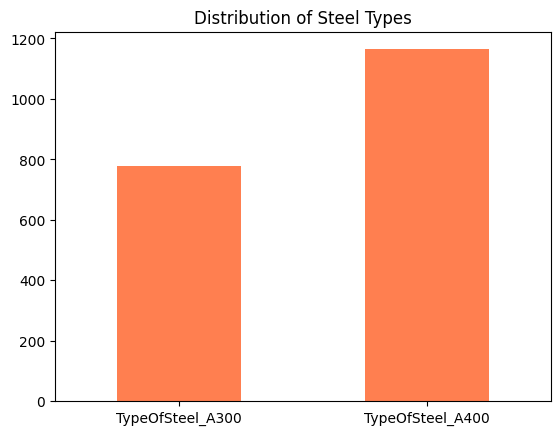

In [24]:
steel_cols = ['TypeOfSteel_A300', 'TypeOfSteel_A400']
d[steel_cols].sum().plot(kind='bar', color='coral')
plt.title("Distribution of Steel Types")
plt.xticks(rotation=0)
plt.show()

In [25]:
d.columns

Index(['X_Maximum', 'Pixels_Areas', 'Y_Perimeter', 'Minimum_of_Luminosity',
       'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300',
       'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index',
       'Empty_Index', 'Outside_X_Index', 'Edges_Y_Index',
       'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index',
       'Orientation_Index', 'Luminosity_Index', 'Fault_Types'],
      dtype='object')

In [26]:
d.dtypes

,0
X_Maximum,int64
Pixels_Areas,int64
Y_Perimeter,int64
Minimum_of_Luminosity,int64
Maximum_of_Luminosity,int64
Length_of_Conveyer,int64
TypeOfSteel_A300,int64
TypeOfSteel_A400,int64
Steel_Plate_Thickness,int64
Edges_Index,float64


In [27]:
reverse_mapping = {v: k for k, v in mapping.items()}
d['Fault_Label'] = d['Fault_Types'].map(reverse_mapping)
d['Fault_Label']=d['Fault_Label'].astype('str')

In [28]:
d.dtypes

,0
X_Maximum,int64
Pixels_Areas,int64
Y_Perimeter,int64
Minimum_of_Luminosity,int64
Maximum_of_Luminosity,int64
Length_of_Conveyer,int64
TypeOfSteel_A300,int64
TypeOfSteel_A400,int64
Steel_Plate_Thickness,int64
Edges_Index,float64


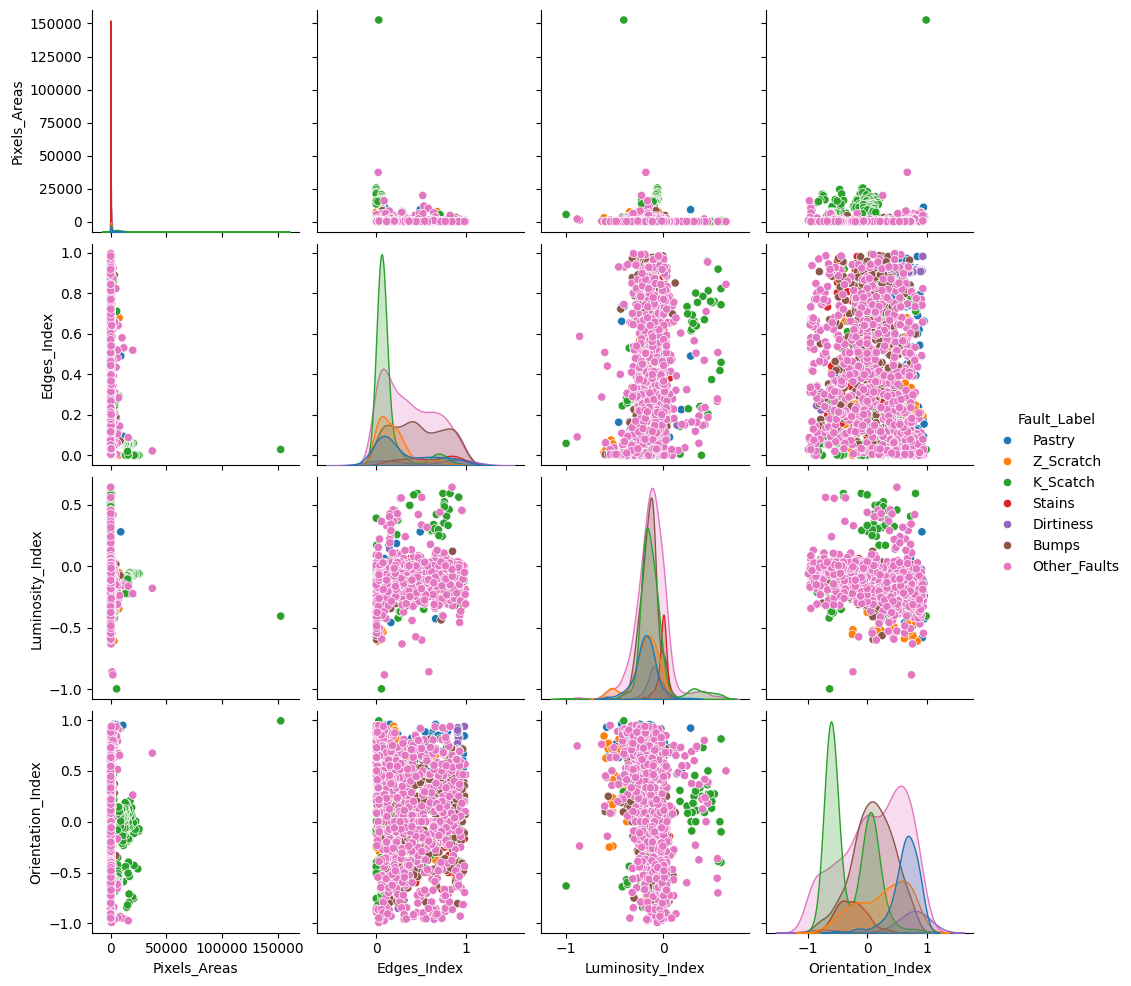

In [29]:
sns.pairplot(d[['Pixels_Areas', 'Edges_Index', 'Luminosity_Index', 'Orientation_Index','Fault_Label']], hue='Fault_Label')
plt.show()

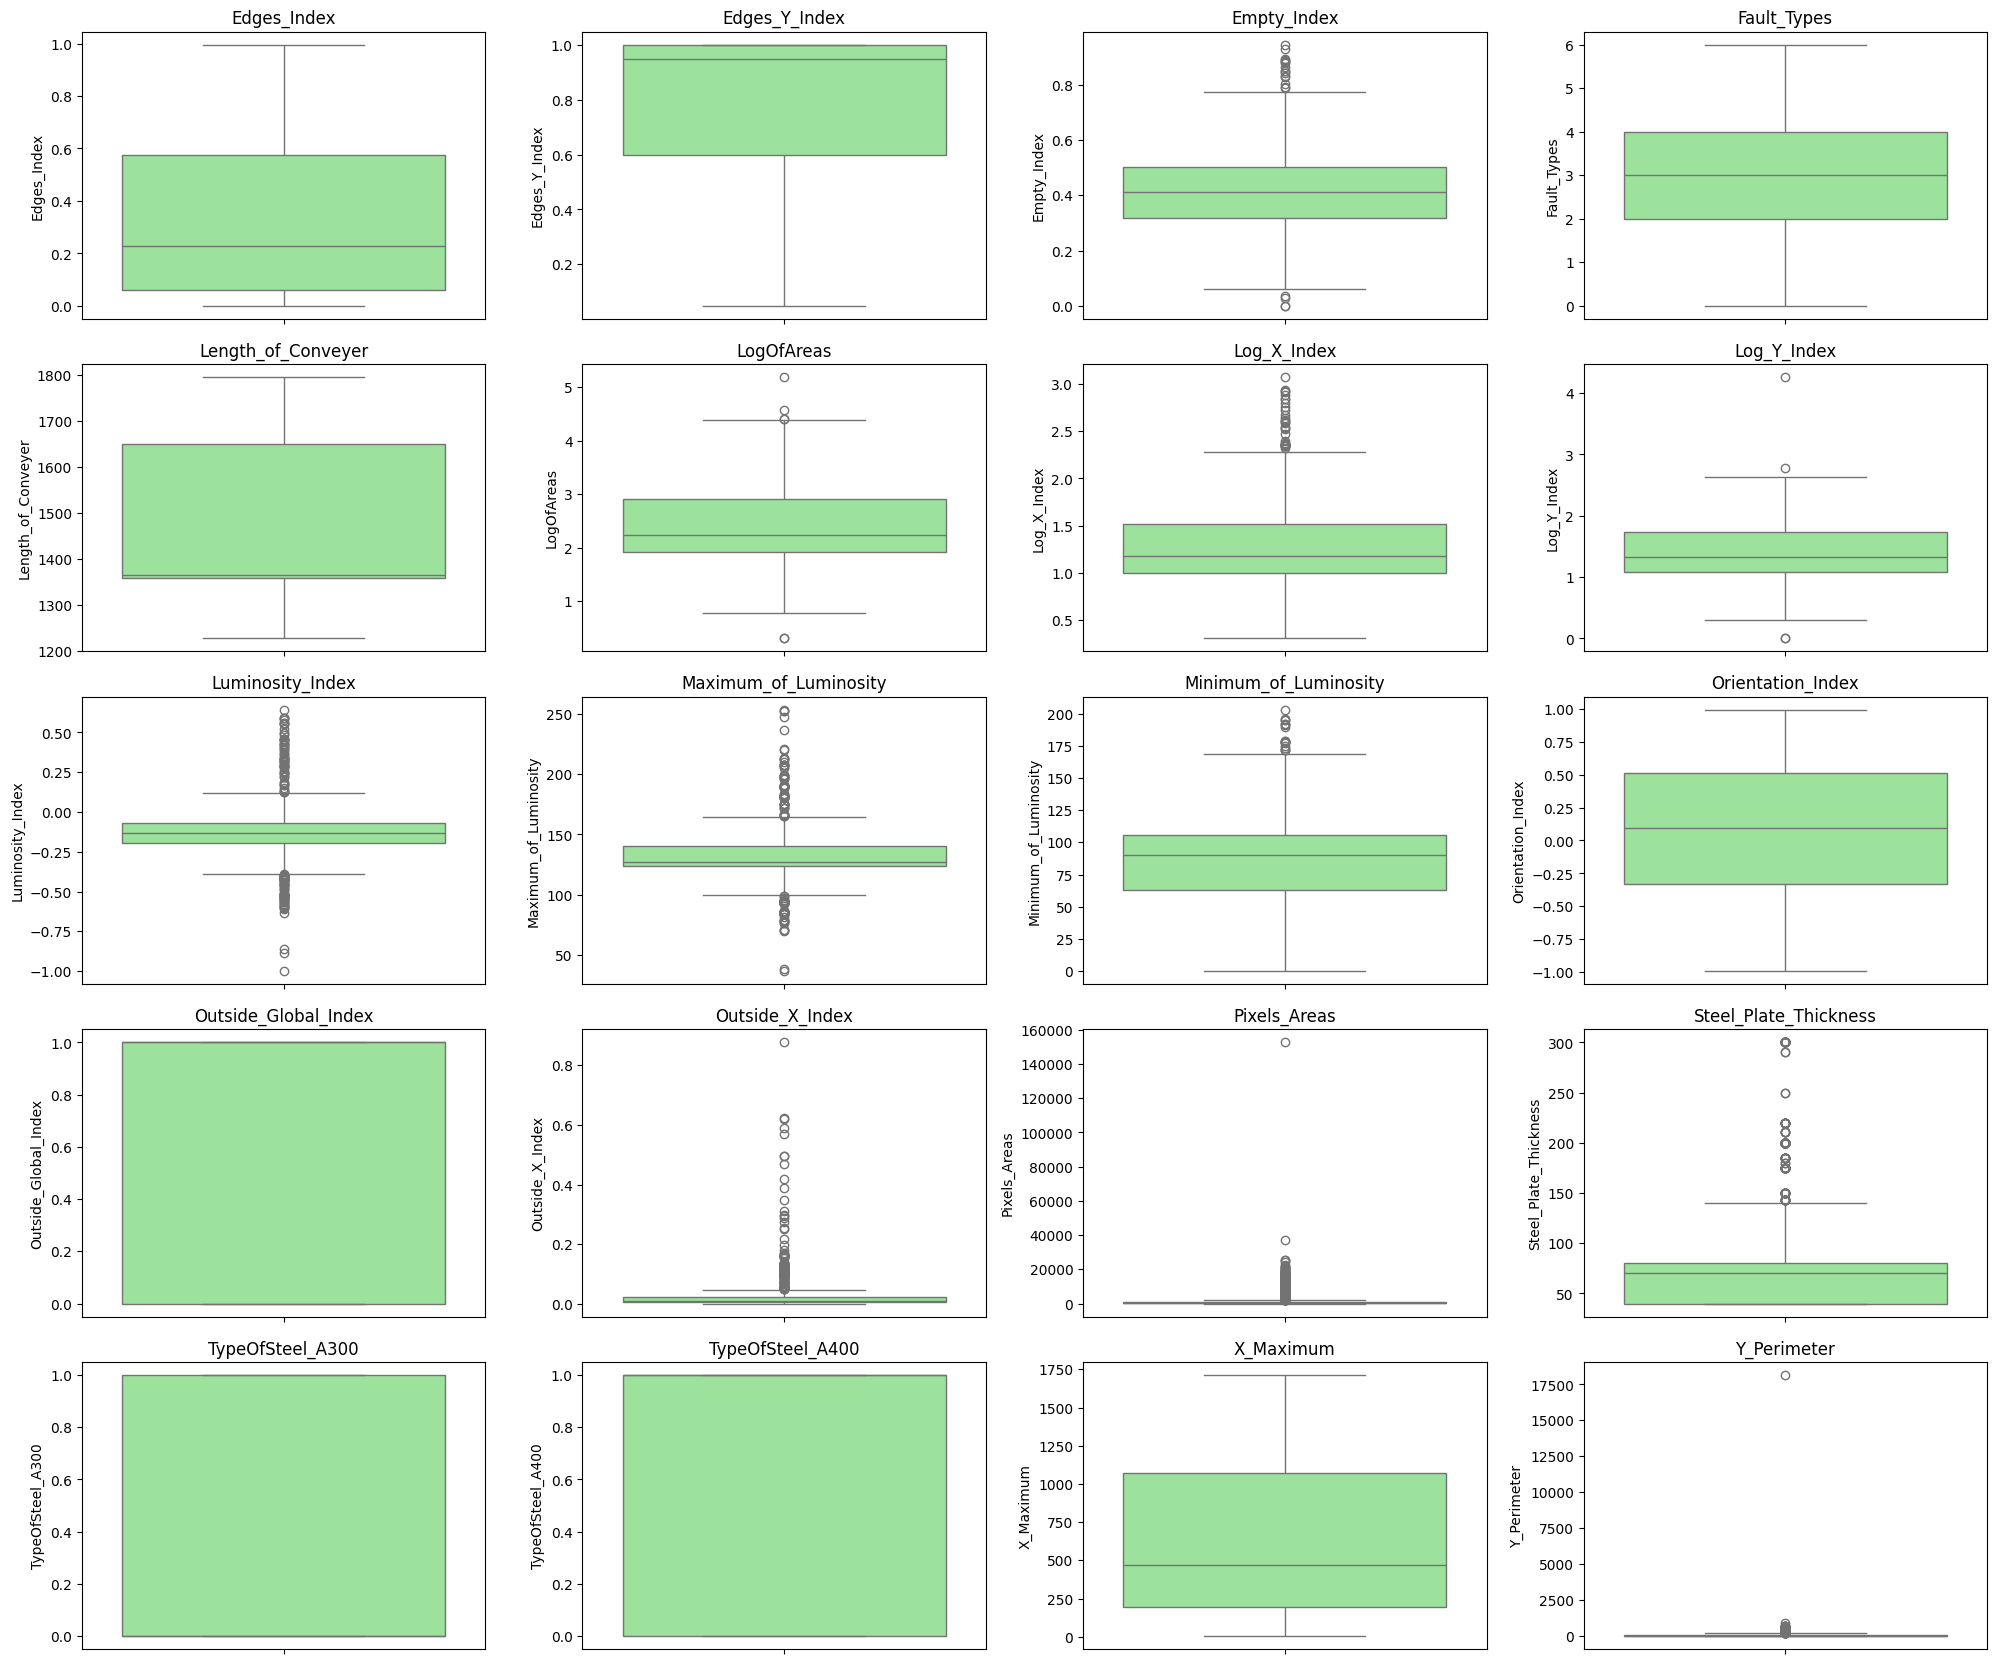

In [30]:
numeric_cols = d.select_dtypes(include=np.number).columns.difference(fault_cols)
plt.figure(figsize=(20, 30))
for i, col in enumerate(numeric_cols):
    plt.subplot(9, 4, i+1)
    sns.boxplot(y=d[col], color="lightgreen")
    plt.title(col)
plt.tight_layout()
plt.show()

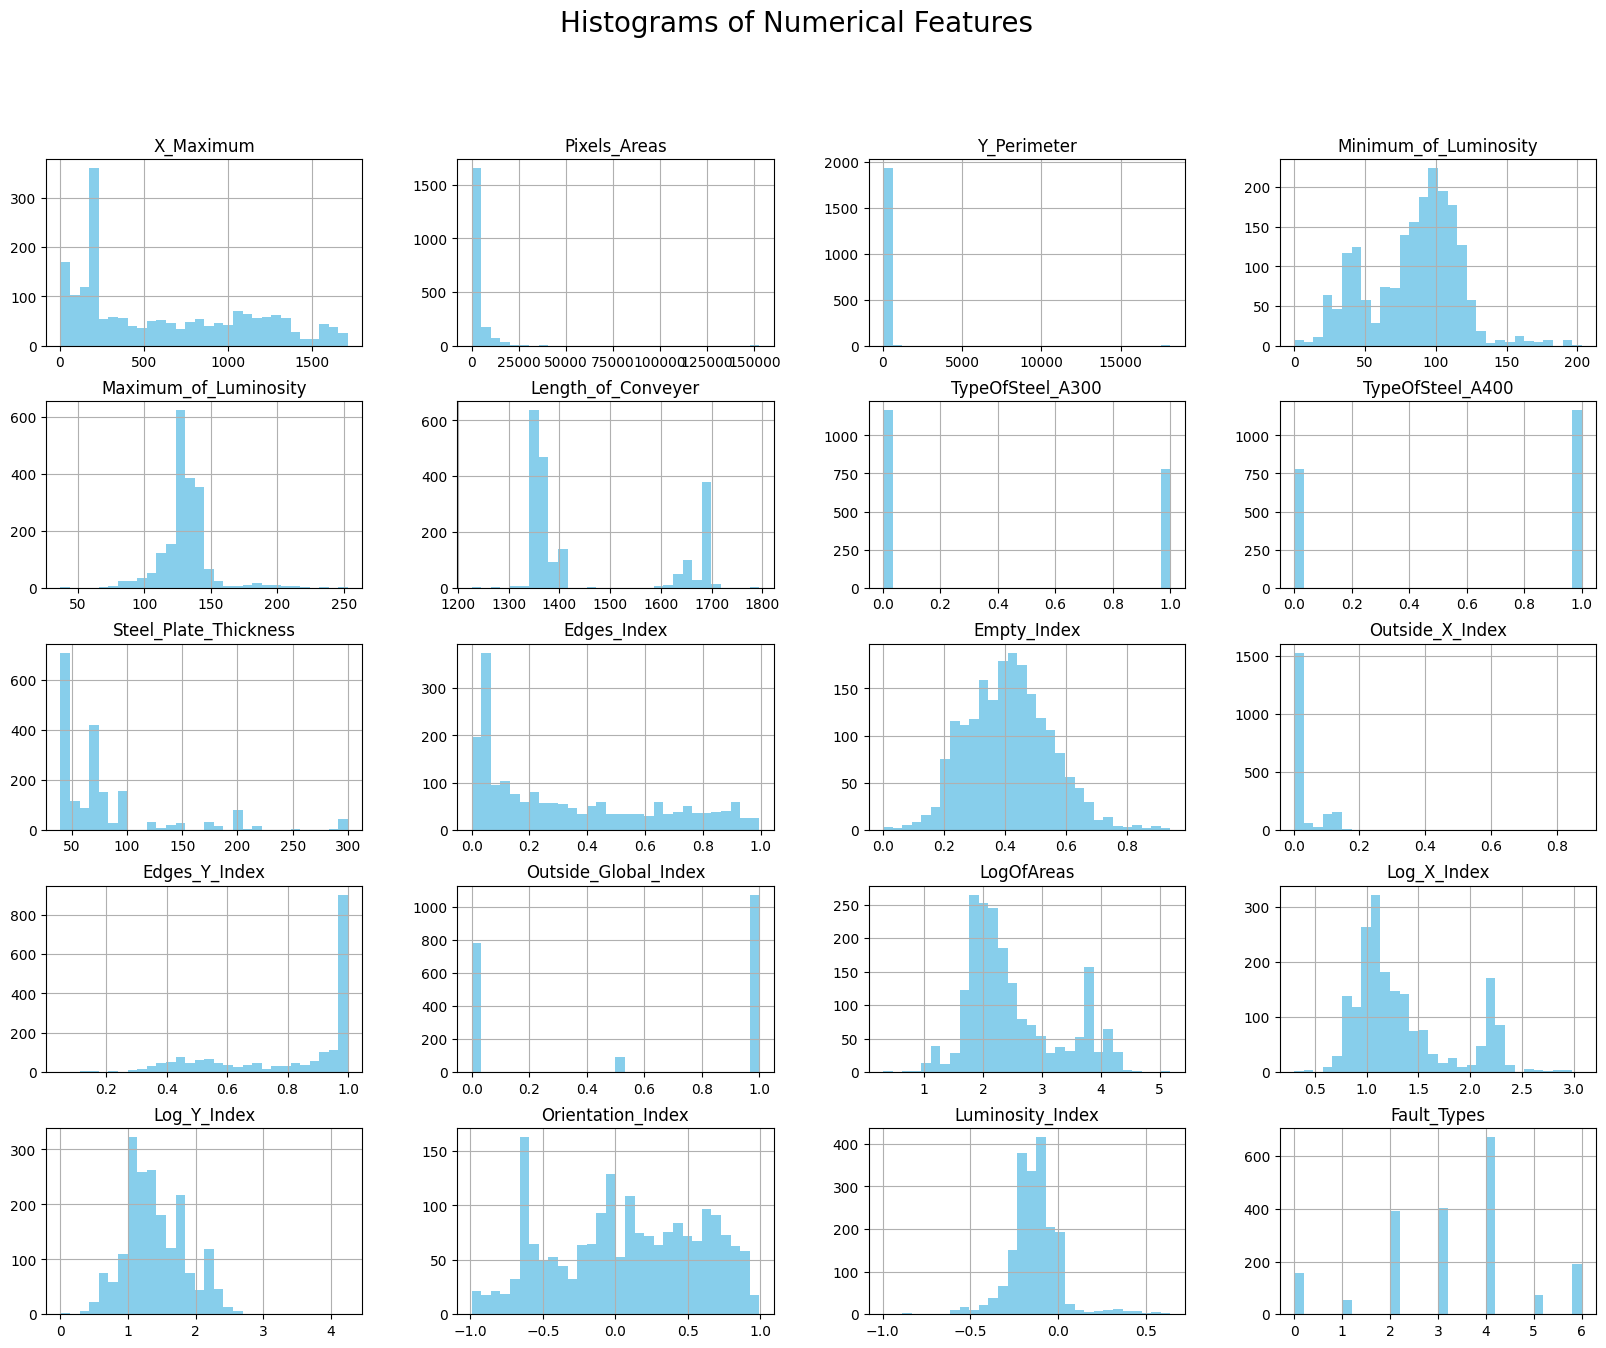

In [31]:
d.select_dtypes(include='number').hist(bins=30, figsize=(20, 15), color='skyblue')
plt.suptitle("Histograms of Numerical Features", fontsize=20)
plt.show()

Data Preprocessing using StandardScaler and EDA

In [33]:
X = d.drop(columns=['Fault_Types']+['Fault_Label'])
y = d['Fault_Types']

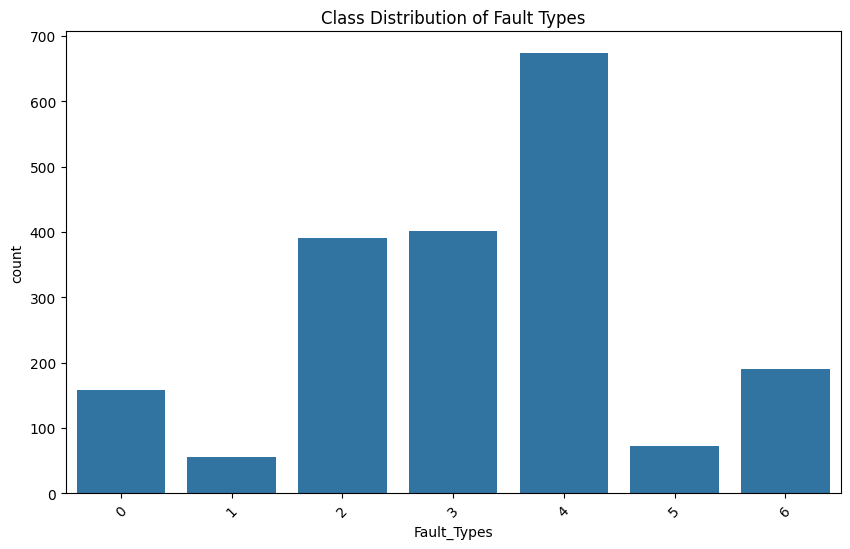

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x=y)
plt.title('Class Distribution of Fault Types')
plt.xticks(rotation=45)
plt.show()

In [36]:
for i in X.columns:
    q1, q3 = X[i].quantile([0.01, 0.99])
    X[i] = X[i].clip(q1, q3)

In [37]:
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
s=StandardScaler()
X_scaled=s.fit_transform(X)

In [40]:
X_scaled

array([[-1.14223853, -0.41195775, -0.25805796, ...,  0.54104174,
         1.47003884, -1.13111939],
       [ 0.06668374, -0.45500083, -0.38241013, ...,  0.13449659,
         1.4198291 , -0.31273228],
       [ 0.43680303, -0.46501715, -0.4801154 , ..., -0.33041506,
         1.16698002,  0.06074084],
       ...,
       [-0.89281031, -0.40518997, -0.45346851, ..., -0.50820841,
        -1.13246626,  0.96613021],
       [-0.90085638, -0.37080965, -0.23141107, ...,  0.19959769,
        -0.28790235,  0.8083944 ],
       [ 1.33394002, -0.45635439, -0.45346851, ..., -0.44535218,
        -0.56675647,  0.12369369]])

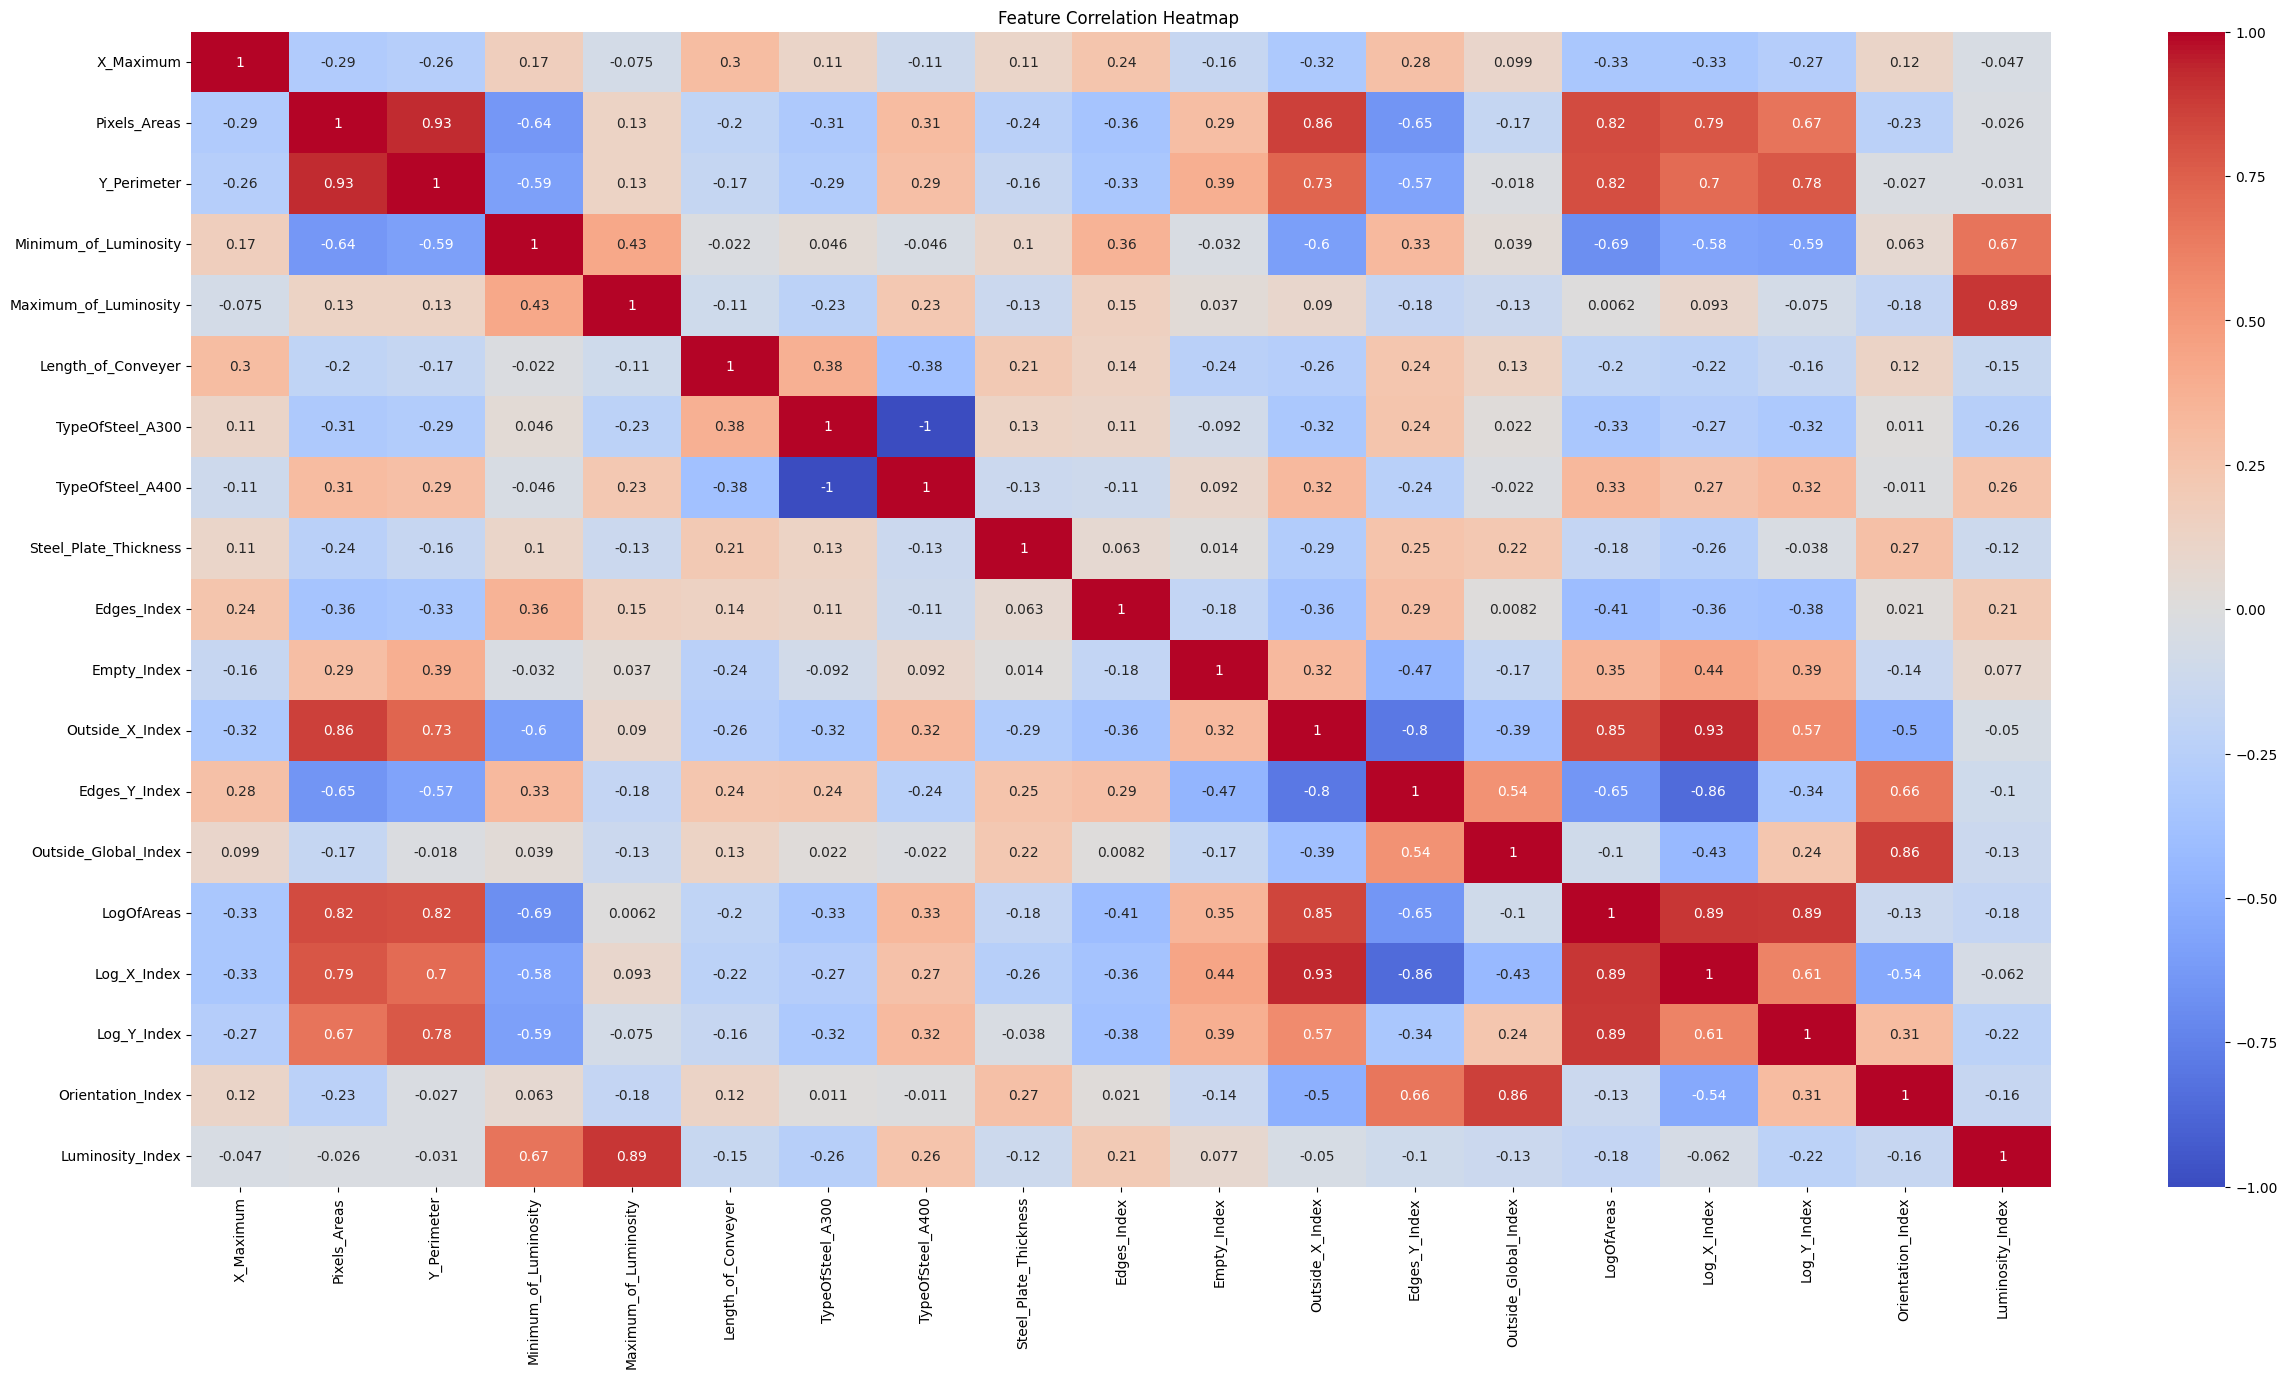

In [41]:
plt.figure(figsize=(30, 15))
correlation_matrix = np.corrcoef(X_scaled.T)
sns.heatmap(correlation_matrix, annot=True,xticklabels=X.columns, yticklabels=X.columns, cmap='coolwarm')
plt.title('Feature Correlation Heatmap ')
plt.show()

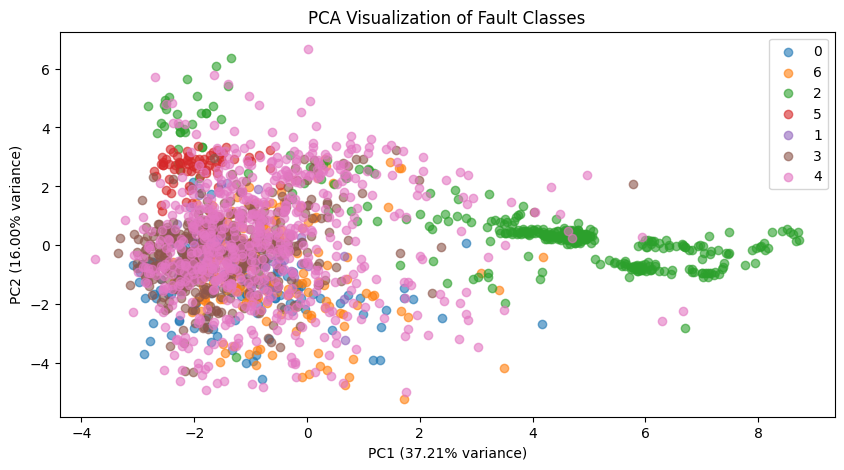

In [42]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca= pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 5))
for i in y.unique():
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=i, alpha=0.6)
plt.title('PCA Visualization of Fault Classes')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend()
plt.show()

Handling Class imbalance using SMOTE

In [43]:
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold

In [44]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,stratify=y,random_state=42)

In [45]:
X_train.shape

(1552, 19)

In [46]:
X_test.shape

(389, 19)

In [47]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_val, y_val= smote.fit_resample(X_train,y_train)

In [48]:
X_val.shape

(3766, 19)

Model Building using SVM,RandomForest and XGBoost Classifier

In [49]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [50]:
models = {
    'SVM': OneVsRestClassifier(SVC(class_weight='balanced',probability=True, random_state=42)),
    'Random Forest': OneVsRestClassifier(RandomForestClassifier(class_weight='balanced', random_state=42)),
    'XGBoost': OneVsRestClassifier(XGBClassifier(eval_metric='logloss', random_state=42)),
}

Hypertuning using GridSearchCV

In [51]:
param_grids = {
    'SVM': {
        'estimator__C': [0.1, 1, 10],
        'estimator__gamma': [0.01, 0.1],
        'estimator__kernel': ['rbf']
    },
    'Random Forest': {
        'estimator__n_estimators': [100, 200],
        'estimator__max_depth': [10, None],
        'estimator__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'estimator__n_estimators': [100, 200],
        'estimator__max_depth': [3, 5],
        'estimator__learning_rate': [0.01, 0.05, 0.1]
    },
}

Finding Best model parameters

In [52]:
best_model={}
for i, model in models.items():
    g=GridSearchCV(estimator=model, param_grid=param_grids[i],cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),scoring='f1_macro',verbose=1,n_jobs=-1)
    g.fit(X_val, y_val)
    best_model[i] = g.best_estimator_
    print(f'Best parameters for {i}: {g.best_params_}')
    print(f'Best cross-validation F1-macro score: {g.best_score_:.4f}')

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best parameters for SVM: {'estimator__C': 10, 'estimator__gamma': 0.1, 'estimator__kernel': 'rbf'}
Best cross-validation F1-macro score: 0.9093
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best parameters for Random Forest: {'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Best cross-validation F1-macro score: 0.9176
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best parameters for XGBoost: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 5, 'estimator__n_estimators': 200}
Best cross-validation F1-macro score: 0.9226


Model Evaluation using various metrics

In [64]:
from sklearn.metrics import accuracy_score,classification_report,hamming_loss,confusion_matrix,f1_score
for i, model in best_model.items():
    y_pred = model.predict(X_test)
    print(f'\n{i} Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f"\n{i} f1-score(weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f'\n{i} Hamming_loss: {hamming_loss(y_test, y_pred):.4f}')
    print(f'Classification Report for {i}:\n', classification_report(y_test, y_pred))
    print(f'Confusion Matrix for {i}:\n', confusion_matrix(y_test, y_pred))


SVM Accuracy: 0.7609

SVM f1-score(weighted): 0.7604

SVM Hamming_loss: 0.2391
Classification Report for SVM:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72        32
           1       0.69      0.82      0.75        11
           2       0.97      0.96      0.97        78
           3       0.64      0.63      0.63        81
           4       0.71      0.67      0.69       135
           5       0.92      0.86      0.89        14
           6       0.81      0.89      0.85        38

    accuracy                           0.76       389
   macro avg       0.78      0.80      0.79       389
weighted avg       0.76      0.76      0.76       389

Confusion Matrix for SVM:
 [[24  0  0  4  4  0  0]
 [ 0  9  0  0  2  0  0]
 [ 0  0 75  0  3  0  0]
 [ 3  1  0 51 25  0  1]
 [ 8  3  2 23 91  1  7]
 [ 0  0  0  1  1 12  0]
 [ 0  0  0  1  3  0 34]]

Random Forest Accuracy: 0.8021

Random Forest f1-score(weighted): 0.8018

Random Forest Hammin

Stacking for improve predictive performance by combining multiple models


Stacking Classifier Hamming Loss: 0.2031
Stacking Classifier Subset Accuracy: 0.7969
Classification Report for Stacking Classifier:
               precision    recall  f1-score   support

      Pastry       0.67      0.62      0.65        32
   Z_Scratch       0.75      0.82      0.78        11
    K_Scatch       0.99      0.96      0.97        78
      Stains       0.70      0.69      0.70        81
   Dirtiness       0.72      0.76      0.74       135
       Bumps       0.92      0.86      0.89        14
Other_Faults       0.97      0.95      0.96        38

    accuracy                           0.80       389
   macro avg       0.82      0.81      0.81       389
weighted avg       0.80      0.80      0.80       389



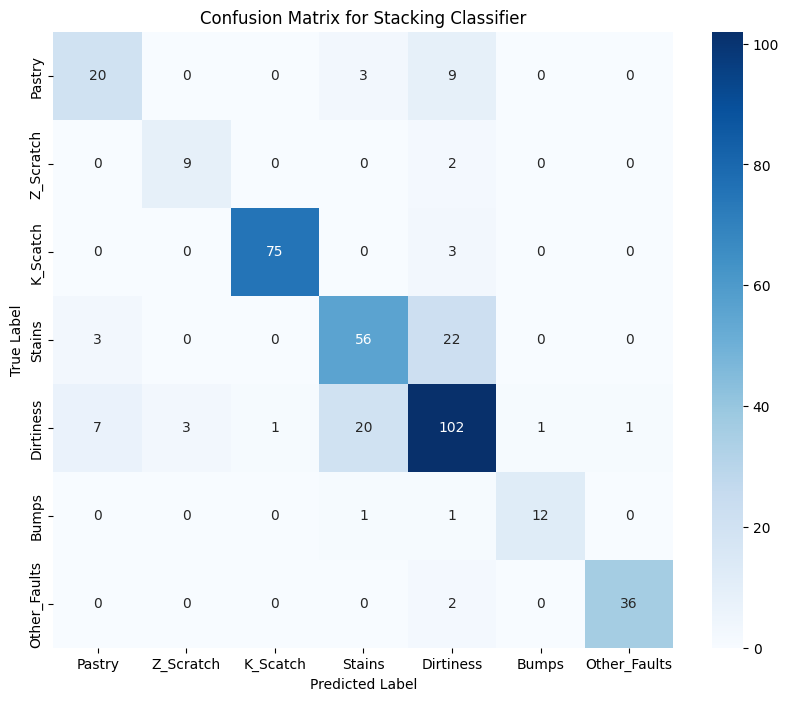

In [65]:
stacking_clf = StackingClassifier(estimators=[
    ('svm', SVC(probability=True, C=best_model['SVM'].estimator.C, gamma=best_model['SVM'].estimator.gamma, kernel=best_model['SVM'].estimator.kernel, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=best_model['Random Forest'].estimator.n_estimators, max_depth=best_model['Random Forest'].estimator.max_depth, min_samples_split=best_model['Random Forest'].estimator.min_samples_split, class_weight='balanced', random_state=42)),
    ('xgb', XGBClassifier(n_estimators=best_model['XGBoost'].estimator.n_estimators, max_depth=best_model['XGBoost'].estimator.max_depth, learning_rate=best_model['XGBoost'].estimator.learning_rate, subsample=best_model['XGBoost'].estimator.subsample, eval_metric='logloss', random_state=42))
])
stacking_clf.fit(X_val, y_val)
y_pred_stacking = stacking_clf.predict(X_test)
print(f'\nStacking Classifier Hamming Loss: {hamming_loss(y_test, y_pred_stacking):.4f}')
print(f'Stacking Classifier Subset Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}')
print(f'Classification Report for Stacking Classifier:\n', classification_report(y_test, y_pred_stacking, target_names=fault_cols))
plt.figure(figsize=(10, 8))
cm_stacking = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Blues', xticklabels=fault_cols, yticklabels=fault_cols)
plt.title('Confusion Matrix for Stacking Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [68]:
joblib.dump(stacking_clf, 'model.pkl')
joblib.dump(s, 'scaler.pkl')
print(' model.pkl and scaler.pkl saved successfully!')

 model.pkl and scaler.pkl saved successfully!


Intepretability and visualisation

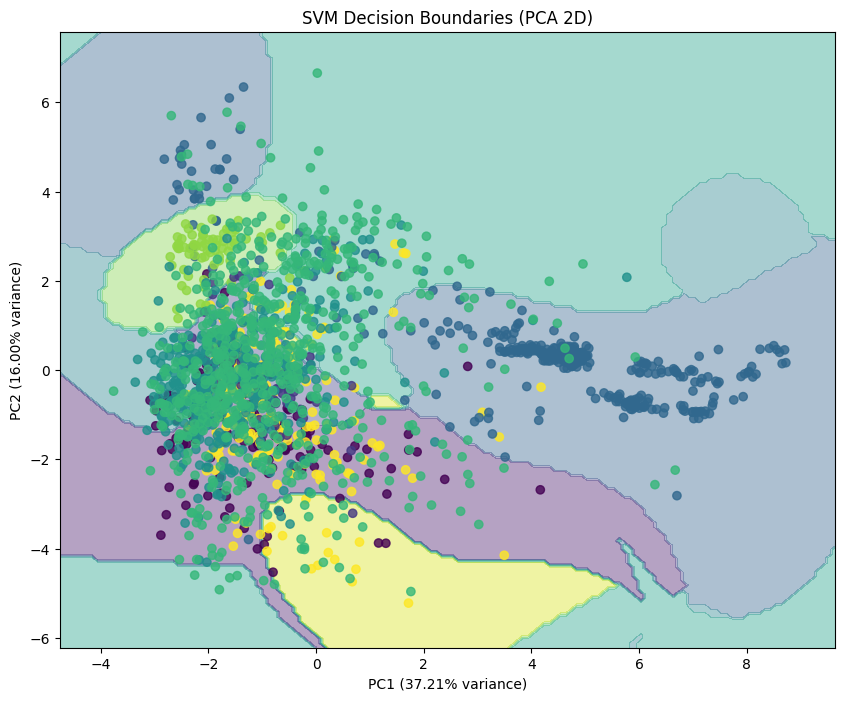

In [67]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
svm_2d = SVC(kernel=best_model['SVM'].estimator.kernel, C=best_model['SVM'].estimator.C, gamma=best_model['SVM'].estimator.gamma, class_weight='balanced', random_state=42)
svm_2d.fit(X_pca, y)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([np.where(svm_2d.classes_ == z)[0][0] for z in Z]).reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=[np.where(svm_2d.classes_ == z)[0][0] for z in y], cmap='viridis', alpha=0.8)
plt.title('SVM Decision Boundaries (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f6a770777c4ea6505619417abfd96717b1f1e278eabf36dff472427d3eecaf84
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


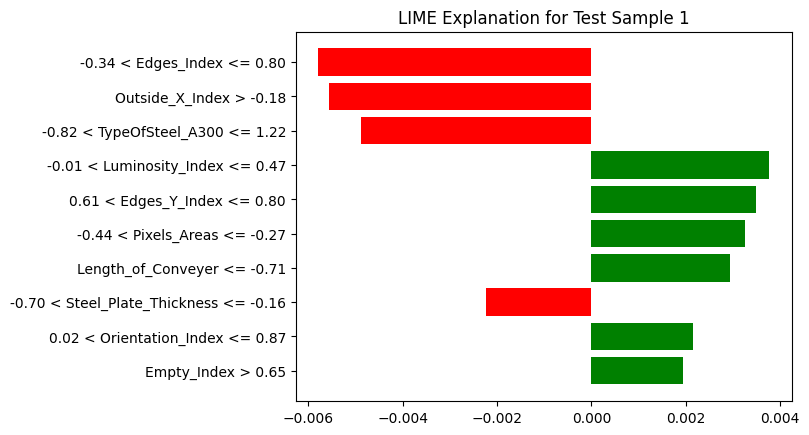

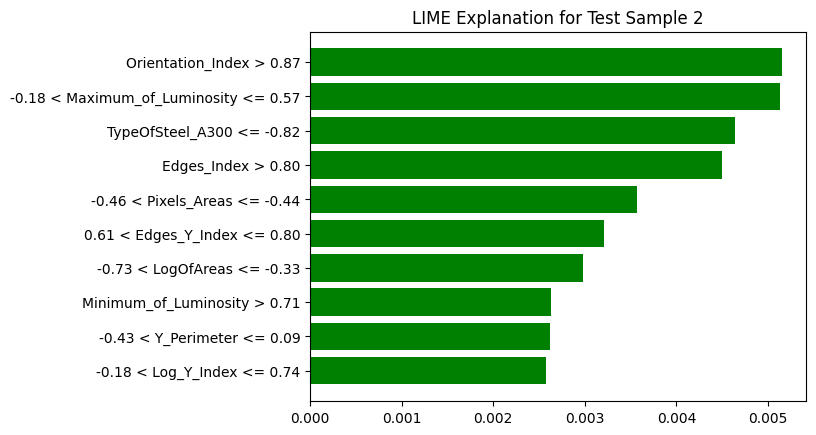

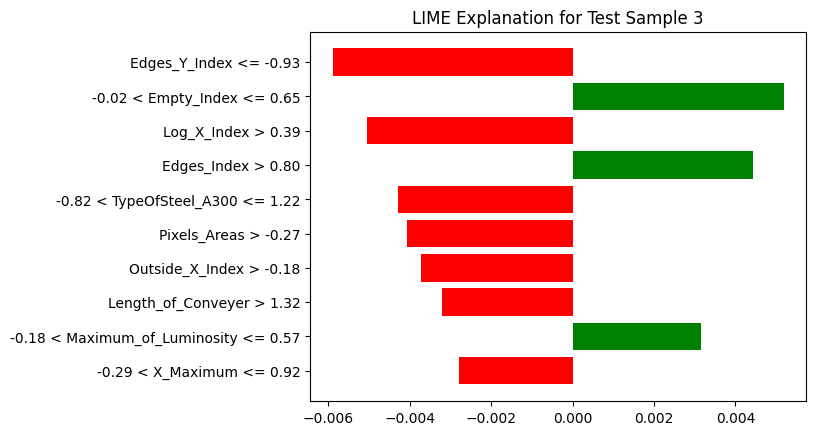

In [57]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train, feature_names=X.columns, class_names=fault_cols, mode='classification')
for idx in range(3):
    exp = explainer.explain_instance(X_test[idx], best_model['SVM'].predict_proba, num_features=10)
    fig = exp.as_pyplot_figure()
    plt.title(f'LIME Explanation for Test Sample {idx + 1}')
    plt.show()

Submission file created with id and their respected fault

In [58]:
y_pred = y_pred_stacking
submission = pd.DataFrame({
    'Id':range(len(y_pred)),
    'Predicted': y_pred
})

In [59]:
submission['Predicted_Label'] = submission['Predicted'].map(reverse_mapping)

In [60]:
submission.to_csv('submission.csv', index=False)

In [61]:
submission.shape

(389, 3)

In [62]:
submission.head()

,Id,Predicted,Predicted_Label
0,0,6,Z_Scratch
1,1,1,Dirtiness
2,2,3,Bumps
3,3,4,Other_Faults
4,4,4,Other_Faults


<Axes: xlabel='Predicted_Label'>

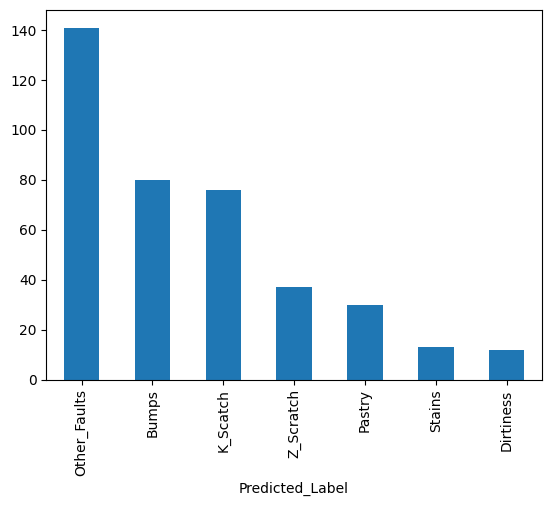

In [63]:
submission['Predicted_Label'].value_counts().plot(kind='bar')